# R Programming Lab 7
## Customer Segmentation and Predictive Analytics Using Machine Learning

**Name:** Prerna Kale  
**Roll No.:** 24102B2001  


In [1]:
# Install required packages
packages <- c(
  "readxl", "tidyverse", "lubridate", "cluster", "factoextra",
  "caret", "randomForest", "e1071", "plotly", "pROC", "scales"
)

new_packages <- packages[!(packages %in% installed.packages()[, "Package"])]
if(length(new_packages)) install.packages(new_packages, repos = "https://cloud.r-project.org")

library(readxl)
library(tidyverse)
library(lubridate)
library(cluster)
library(factoextra)
library(caret)
library(randomForest)
library(e1071)
library(plotly)
library(pROC)
library(scales)

set.seed(42)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘future’, ‘globals’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘diagram’, ‘lava’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘showtextdb’, ‘corrplot’, ‘prodlim’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘lazyeval’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘proxy’, ‘crosstalk’


── Attaching co

In [2]:
data_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
file_path <- "Online_Retail.xlsx"

if(!file.exists(file_path)) {
  download.file(data_url, file_path, mode = "wb")
}

retail <- read_excel(file_path)

cat("Rows:", nrow(retail), "\n")
cat("Columns:", ncol(retail), "\n")
head(retail)

Rows: 541909 
Columns: 8 


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


In [3]:
str(retail)
summary(retail)

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


     InvoiceNo          StockCode         Description        Quantity         
 Length   :541909   Length   :541909   Length   :541909   Min.   :-80995.000  
 N.unique : 25900   N.unique :  4070   N.unique :  4211   1st Qu.:     1.000  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :     3.000  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     1   Mean   :     9.552  
 Max.nchar:     7   Max.nchar:    12   Max.nchar:    35   3rd Qu.:    10.000  
                                       NAs      :  1454   Max.   : 80995.000  
                                                                              
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:

In [4]:
missing_summary <- data.frame(
  Column = names(retail),
  Missing = sapply(retail, function(x) sum(is.na(x))),
  Missing_Percent = round(sapply(retail, function(x) mean(is.na(x)) * 100), 2)
)

missing_summary

,Column,Missing,Missing_Percent
,<chr>,<int>,<dbl>
InvoiceNo,InvoiceNo,0,0.00
StockCode,StockCode,0,0.00
Description,Description,1454,0.27
Quantity,Quantity,0,0.00
InvoiceDate,InvoiceDate,0,0.00
UnitPrice,UnitPrice,0,0.00
CustomerID,CustomerID,135080,24.93
Country,Country,0,0.00


In [5]:
retail_clean <- retail %>%
  mutate(
    InvoiceNo = as.character(InvoiceNo),
    CustomerID = as.character(CustomerID),
    InvoiceDate = as.POSIXct(InvoiceDate),
    Quantity = as.numeric(Quantity),
    UnitPrice = as.numeric(UnitPrice)
  ) %>%
  filter(
    !is.na(CustomerID),
    !grepl("^C", InvoiceNo, ignore.case = TRUE),
    !is.na(Description),
    Quantity > 0,
    UnitPrice > 0
  ) %>%
  mutate(
    Revenue = Quantity * UnitPrice
  )

cat("Original rows:", nrow(retail), "\n")
cat("Rows after preprocessing:", nrow(retail_clean), "\n")
cat("Customers retained:", n_distinct(retail_clean$CustomerID), "\n")

Original rows: 541909 
Rows after preprocessing: 397884 
Customers retained: 4338 


In [6]:
summary(retail_clean[, c("Quantity", "UnitPrice", "Revenue")])

    Quantity          UnitPrice           Revenue         
 Min.   :    1.00   Min.   :   0.001   Min.   :1.000e-03  
 1st Qu.:    2.00   1st Qu.:   1.250   1st Qu.:4.680e+00  
 Median :    6.00   Median :   1.950   Median :1.180e+01  
 Mean   :   12.99   Mean   :   3.116   Mean   :2.240e+01  
 3rd Qu.:   12.00   3rd Qu.:   3.750   3rd Qu.:1.980e+01  
 Max.   :80995.00   Max.   :8142.750   Max.   :1.685e+05  

In [7]:
analysis_date <- max(retail_clean$InvoiceDate) + days(1)

customer_features <- retail_clean %>%
  group_by(CustomerID) %>%
  summarise(
    LastPurchase = max(InvoiceDate),
    Recency = as.numeric(difftime(analysis_date, LastPurchase, units = "days")),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(Revenue),
    AvgTransactionValue = Monetary / Frequency,
    TotalQuantity = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    ActiveMonths = n_distinct(floor_date(InvoiceDate, "month")),
    .groups = "drop"
  ) %>%
  mutate(
    PurchaseFrequency = Frequency / ActiveMonths
  ) %>%
  select(-LastPurchase)

head(customer_features)

CustomerID,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,UniqueProducts,ActiveMonths,PurchaseFrequency
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
12346,326.117361,1,77183.60,77183.6000,74215,1,1,1
12347,2.873611,7,4310.00,615.7143,2458,103,7,1
12348,75.984028,4,1797.24,449.3100,2341,22,4,1
12349,19.124306,1,1757.55,1757.5500,631,73,1,1
12350,310.867361,1,334.40,334.4000,197,17,1,1
12352,36.925694,8,2506.04,313.2550,536,59,4,2


In [8]:
customer_features %>%
  summarise(
    Customers = n(),
    AvgRecency = mean(Recency),
    AvgFrequency = mean(Frequency),
    AvgMonetary = mean(Monetary),
    AvgTransactionValue = mean(AvgTransactionValue),
    AvgQuantity = mean(TotalQuantity),
    AvgPurchaseFrequency = mean(PurchaseFrequency)
  )

Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgTransactionValue,AvgQuantity,AvgPurchaseFrequency
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4338,93.04932,4.272015,2054.266,419.1663,1191.289,1.225594


In [9]:
cap_outliers <- function(x) {
  q1 <- quantile(x, 0.25, na.rm = TRUE)
  q3 <- quantile(x, 0.75, na.rm = TRUE)
  iqr_value <- q3 - q1
  lower <- q1 - 1.5 * iqr_value
  upper <- q3 + 1.5 * iqr_value
  x <- pmax(x, lower)
  x <- pmin(x, upper)
  x
}

cluster_features <- c(
  "Recency", "Frequency", "Monetary",
  "AvgTransactionValue", "TotalQuantity",
  "PurchaseFrequency", "UniqueProducts"
)

customer_model <- customer_features %>%
  mutate(across(all_of(cluster_features), cap_outliers))

scaled_features <- scale(customer_model[, cluster_features])
rownames(scaled_features) <- customer_model$CustomerID

cat("Features used for clustering:\n")
print(cluster_features)

Features used for clustering:
[1] "Recency"             "Frequency"           "Monetary"           
[4] "AvgTransactionValue" "TotalQuantity"       "PurchaseFrequency"  
[7] "UniqueProducts"     


Selected number of clusters: 4 


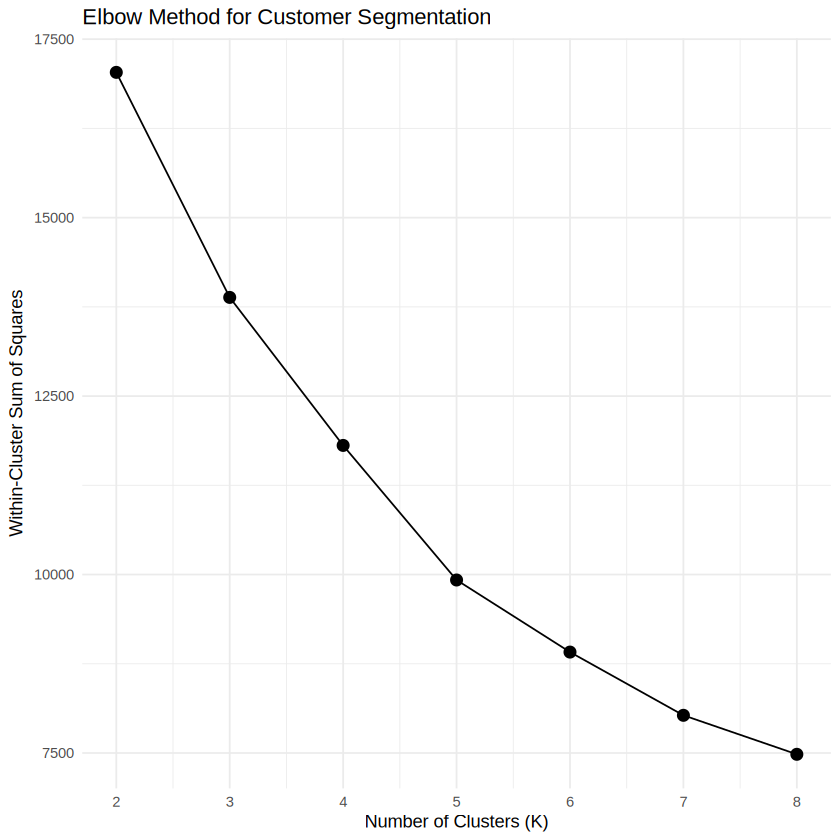

In [10]:
wss <- sapply(2:8, function(k) {
  kmeans(scaled_features, centers = k, nstart = 25)$tot.withinss
})

elbow_data <- data.frame(K = 2:8, WSS = wss)

ggplot(elbow_data, aes(K, WSS)) +
  geom_line() +
  geom_point(size = 3) +
  scale_x_continuous(breaks = 2:8) +
  labs(
    title = "Elbow Method for Customer Segmentation",
    x = "Number of Clusters (K)",
    y = "Within-Cluster Sum of Squares"
  ) +
  theme_minimal()

# The assignment workflow uses 4 clusters for a useful business segmentation.
optimal_k <- 4
cat("Selected number of clusters:", optimal_k, "\n")

In [11]:
set.seed(42)

kmeans_res <- kmeans(
  scaled_features,
  centers = optimal_k,
  nstart = 50
)

customer_model$Cluster <- factor(kmeans_res$cluster)

cluster_sizes <- customer_model %>%
  count(Cluster, name = "Customers") %>%
  mutate(Percentage = round(Customers / sum(Customers) * 100, 2))

cluster_sizes

Cluster,Customers,Percentage
<fct>,<int>,<dbl>
1,947,21.83
2,1845,42.53
3,771,17.77
4,775,17.87


Hierarchical clustering completed with 4 clusters.


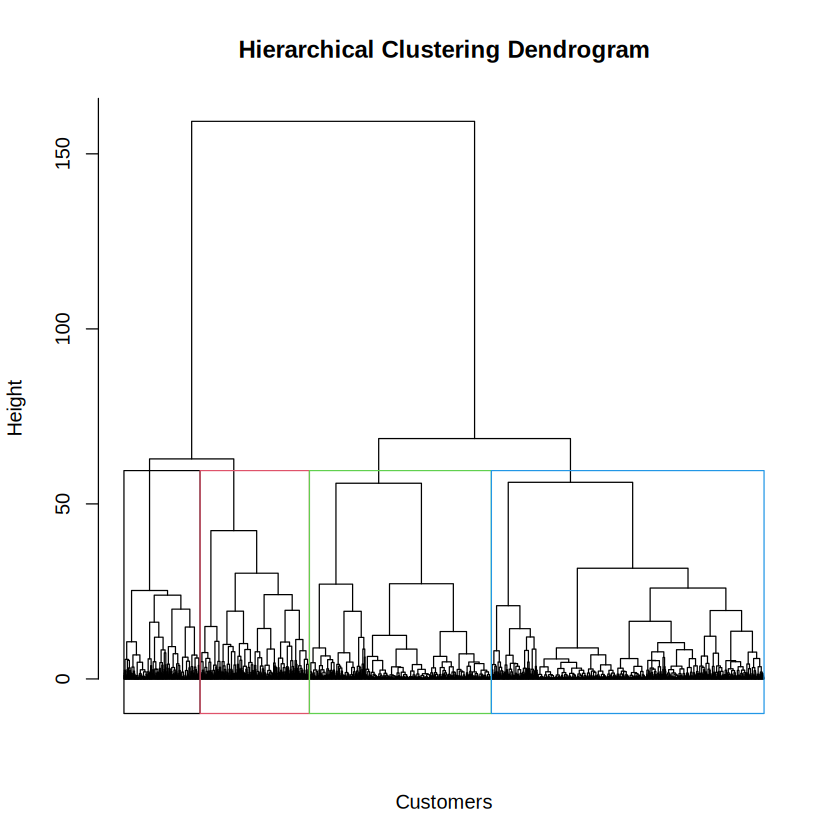

In [12]:
distance_matrix <- dist(scaled_features, method = "euclidean")

hc_res <- hclust(distance_matrix, method = "ward.D2")

plot(
  hc_res,
  labels = FALSE,
  hang = -1,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "Customers",
  sub = ""
)

rect.hclust(hc_res, k = optimal_k, border = 1:optimal_k)

hc_clusters <- cutree(hc_res, k = optimal_k)

customer_model$HC_Cluster <- factor(hc_clusters)

cat("Hierarchical clustering completed with", optimal_k, "clusters.\n")

Average K-Means Silhouette Score: 0.2901 
  cluster size ave.sil.width
1       1  947          0.41
2       2 1845          0.30
3       3  771          0.30
4       4  775          0.12


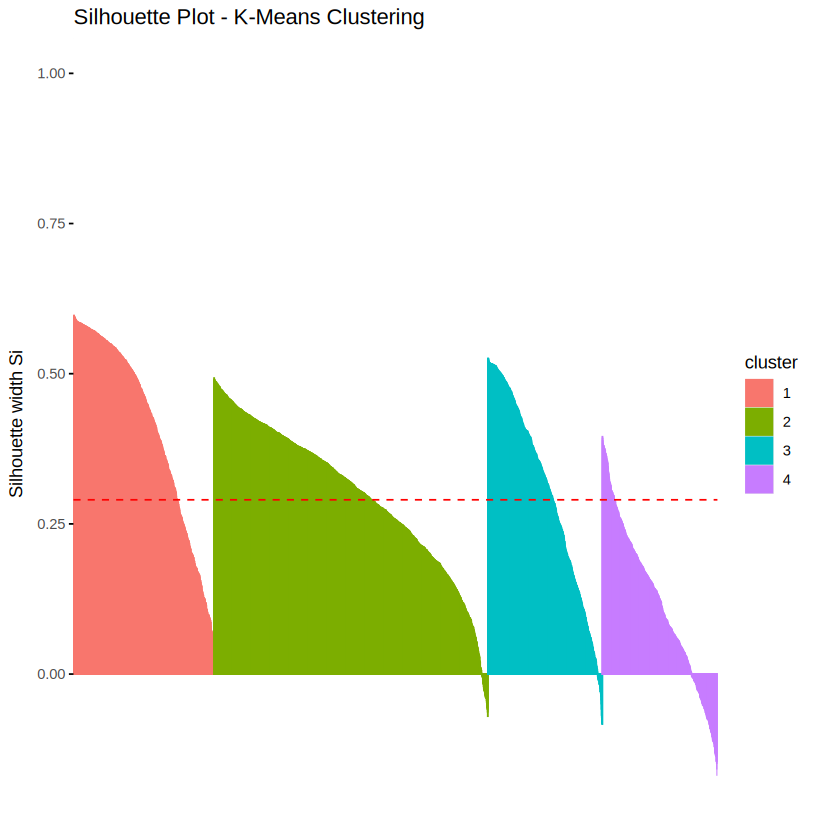

In [13]:
sil_kmeans <- silhouette(kmeans_res$cluster, distance_matrix)
sil_avg <- mean(sil_kmeans[, "sil_width"])

cat("Average K-Means Silhouette Score:", round(sil_avg, 4), "\n")

fviz_silhouette(sil_kmeans) +
  labs(title = "Silhouette Plot - K-Means Clustering")

In [14]:
sil_hc <- silhouette(hc_clusters, distance_matrix)
sil_hc_avg <- mean(sil_hc[, "sil_width"])

comparison <- data.frame(
  Method = c("K-Means", "Hierarchical Clustering"),
  Silhouette_Score = c(sil_avg, sil_hc_avg)
)

comparison

Method,Silhouette_Score
<chr>,<dbl>
K-Means,0.2901121
Hierarchical Clustering,0.2216448


Variance explained by PC1: 59.03 %
Variance explained by PC2: 15.88 %
Variance explained by PC3: 10.98 %


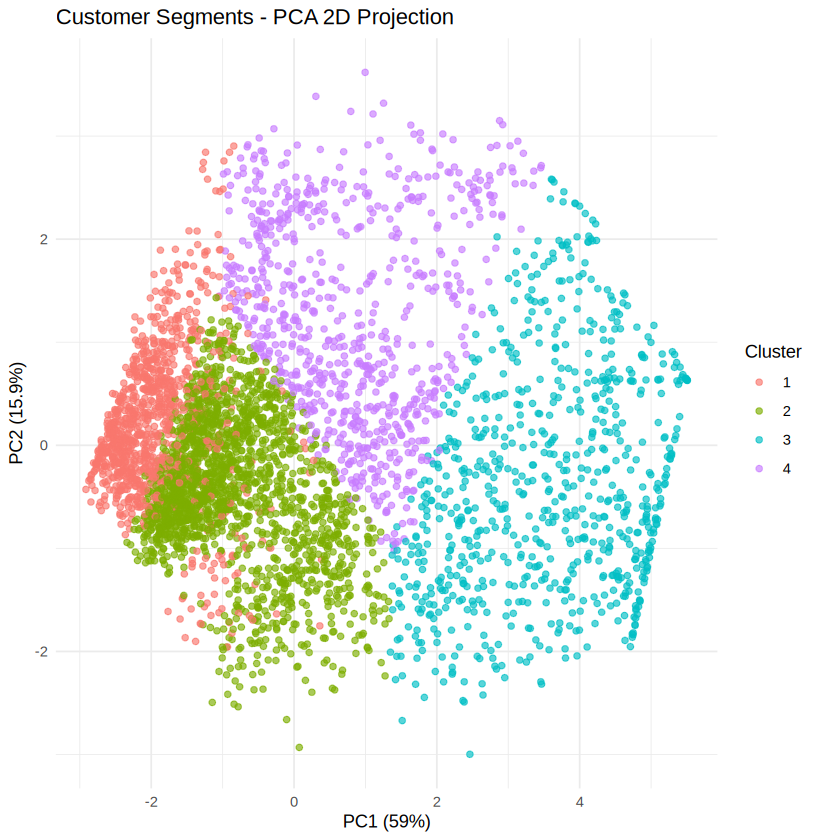

In [15]:
pca_res <- prcomp(scaled_features, center = FALSE, scale. = FALSE)

pca_variance <- summary(pca_res)$importance[2, 1:3] * 100
cat("Variance explained by PC1:", round(pca_variance[1], 2), "%\n")
cat("Variance explained by PC2:", round(pca_variance[2], 2), "%\n")
cat("Variance explained by PC3:", round(pca_variance[3], 2), "%\n")

pca_data <- data.frame(
  PC1 = pca_res$x[, 1],
  PC2 = pca_res$x[, 2],
  PC3 = pca_res$x[, 3],
  Cluster = customer_model$Cluster
)

ggplot(pca_data, aes(PC1, PC2, color = Cluster)) +
  geom_point(alpha = 0.65, size = 1.5) +
  labs(
    title = "Customer Segments - PCA 2D Projection",
    x = paste0("PC1 (", round(pca_variance[1], 1), "%)"),
    y = paste0("PC2 (", round(pca_variance[2], 1), "%)")
  ) +
  theme_minimal()

In [16]:
cluster_profile <- customer_model %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    Recency = mean(Recency),
    Frequency = mean(Frequency),
    Monetary = mean(Monetary),
    AvgTransactionValue = mean(AvgTransactionValue),
    TotalQuantity = mean(TotalQuantity),
    PurchaseFrequency = mean(PurchaseFrequency),
    UniqueProducts = mean(UniqueProducts),
    .groups = "drop"
  )

cluster_profile

Cluster,Customers,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,UniqueProducts
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,947,248.18805,1.374868,322.5573,243.8697,172.3749,1.041887,19.56283
2,1845,49.43259,2.479675,552.1125,236.8786,329.8417,1.099697,35.85203
3,771,23.06724,8.911803,3076.1368,426.8808,1816.2899,1.436010,119.73671
4,775,71.08369,3.067097,1740.5204,578.9053,1030.8408,1.075972,71.71935


In [17]:
# Relative profile using standardized feature means
profile_scaled <- customer_model %>%
  group_by(Cluster) %>%
  summarise(across(all_of(cluster_features), mean), .groups = "drop")

profile_scaled

Cluster,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,UniqueProducts
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,248.18805,1.374868,322.5573,243.8697,172.3749,1.041887,19.56283
2,49.43259,2.479675,552.1125,236.8786,329.8417,1.099697,35.85203
3,23.06724,8.911803,3076.1368,426.8808,1816.2899,1.436010,119.73671
4,71.08369,3.067097,1740.5204,578.9053,1030.8408,1.075972,71.71935


In [18]:
profile_rank <- cluster_profile %>%
  mutate(
    Monetary_Rank = min_rank(desc(Monetary)),
    Frequency_Rank = min_rank(desc(Frequency)),
    Value_Index = Monetary_Rank + Frequency_Rank
  ) %>%
  arrange(Value_Index, desc(Monetary))

high_value_cluster <- as.character(profile_rank$Cluster[1])

cat("High-value cluster identified as:", high_value_cluster, "\n")

customer_model <- customer_model %>%
  mutate(
    IsHighValue = factor(
      ifelse(as.character(Cluster) == high_value_cluster, "Yes", "No"),
      levels = c("No", "Yes")
    )
  )

table(customer_model$IsHighValue)

High-value cluster identified as: 3 



  No  Yes 
3567  771 

In [19]:
model_data <- customer_model %>%
  select(
    all_of(cluster_features),
    IsHighValue
  )

set.seed(101)

train_index <- createDataPartition(
  model_data$IsHighValue,
  p = 0.80,
  list = FALSE
)

train_data <- model_data[train_index, ]
test_data <- model_data[-train_index, ]

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows:", nrow(test_data), "\n")

Training rows: 3471 
Testing rows: 867 


In [20]:
set.seed(101)

rf_model <- randomForest(
  IsHighValue ~ .,
  data = train_data,
  ntree = 300,
  importance = TRUE
)

rf_pred <- predict(rf_model, test_data)
rf_prob <- predict(rf_model, test_data, type = "prob")[, "Yes"]

rf_cm <- confusionMatrix(
  rf_pred,
  test_data$IsHighValue,
  positive = "Yes"
)

rf_cm

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  709   7
       Yes   4 147
                                          
               Accuracy : 0.9873          
                 95% CI : (0.9774, 0.9936)
    No Information Rate : 0.8224          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.9562          
                                          
 Mcnemar's Test P-Value : 0.5465          
                                          
            Sensitivity : 0.9545          
            Specificity : 0.9944          
         Pos Pred Value : 0.9735          
         Neg Pred Value : 0.9902          
             Prevalence : 0.1776          
         Detection Rate : 0.1696          
   Detection Prevalence : 0.1742          
      Balanced Accuracy : 0.9745          
                                          
       'Positive' Class : Yes             
                              

In [21]:
set.seed(101)

svm_model <- svm(
  IsHighValue ~ .,
  data = train_data,
  kernel = "radial",
  probability = TRUE
)

svm_pred <- predict(svm_model, test_data, probability = TRUE)

svm_prob <- attr(
  predict(svm_model, test_data, probability = TRUE),
  "probabilities"
)[, "Yes"]

svm_cm <- confusionMatrix(
  svm_pred,
  test_data$IsHighValue,
  positive = "Yes"
)

svm_cm

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  712   0
       Yes   1 154
                                     
               Accuracy : 0.9988     
                 95% CI : (0.9936, 1)
    No Information Rate : 0.8224     
    P-Value [Acc > NIR] : <2e-16     
                                     
                  Kappa : 0.9961     
                                     
 Mcnemar's Test P-Value : 1          
                                     
            Sensitivity : 1.0000     
            Specificity : 0.9986     
         Pos Pred Value : 0.9935     
         Neg Pred Value : 1.0000     
             Prevalence : 0.1776     
         Detection Rate : 0.1776     
   Detection Prevalence : 0.1788     
      Balanced Accuracy : 0.9993     
                                     
       'Positive' Class : Yes        
                                     

In [22]:
rf_roc <- roc(
  response = test_data$IsHighValue,
  predictor = rf_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

svm_roc <- roc(
  response = test_data$IsHighValue,
  predictor = svm_prob,
  levels = c("No", "Yes"),
  direction = "<"
)

rf_auc <- as.numeric(auc(rf_roc))
svm_auc <- as.numeric(auc(svm_roc))

performance <- data.frame(
  Model = c("Random Forest", "SVM"),
  Accuracy = c(
    unname(rf_cm$byClass["Sensitivity"] * 0 + rf_cm$overall["Accuracy"]),
    unname(svm_cm$byClass["Sensitivity"] * 0 + svm_cm$overall["Accuracy"])
  ),
  Precision = c(
    unname(rf_cm$byClass["Pos Pred Value"]),
    unname(svm_cm$byClass["Pos Pred Value"])
  ),
  Recall = c(
    unname(rf_cm$byClass["Sensitivity"]),
    unname(svm_cm$byClass["Sensitivity"])
  ),
  F1_Score = c(
    unname(rf_cm$byClass["F1"]),
    unname(svm_cm$byClass["F1"])
  ),
  ROC_AUC = c(rf_auc, svm_auc)
)

performance[, -1] <- round(performance[, -1], 4)
performance

Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Random Forest,0.9873,0.9735,0.9545,0.9639,0.9992
SVM,0.9988,0.9935,1.0000,0.9968,1.0000


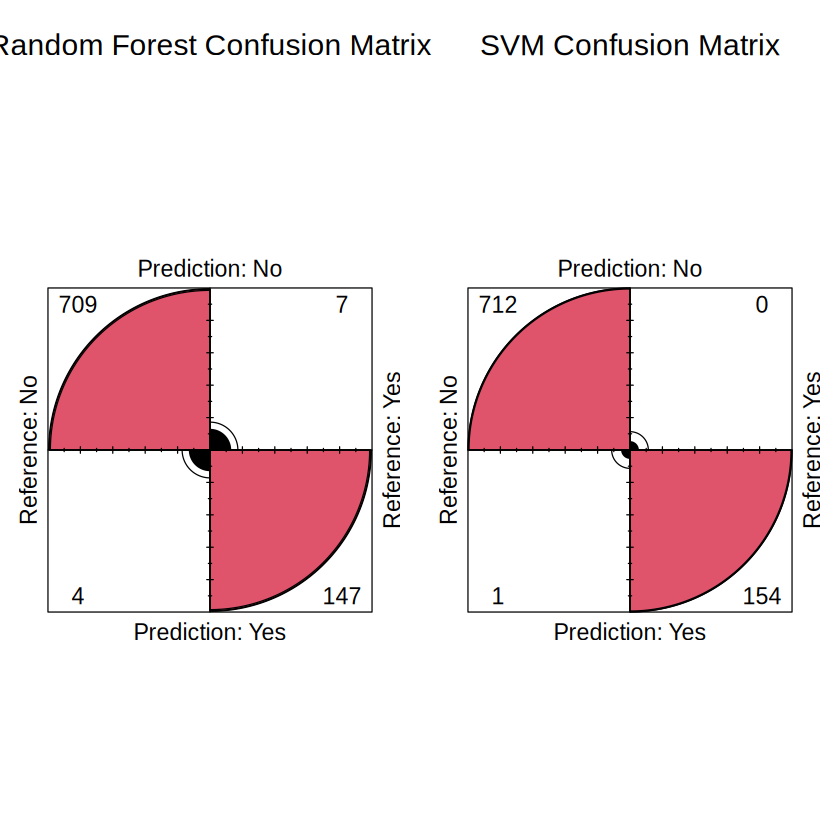

In [23]:
par(mfrow = c(1, 2))

fourfoldplot(
  rf_cm$table,
  color = 1:4,
  main = "Random Forest Confusion Matrix"
)

fourfoldplot(
  svm_cm$table,
  color = 1:4,
  main = "SVM Confusion Matrix"
)

par(mfrow = c(1, 1))

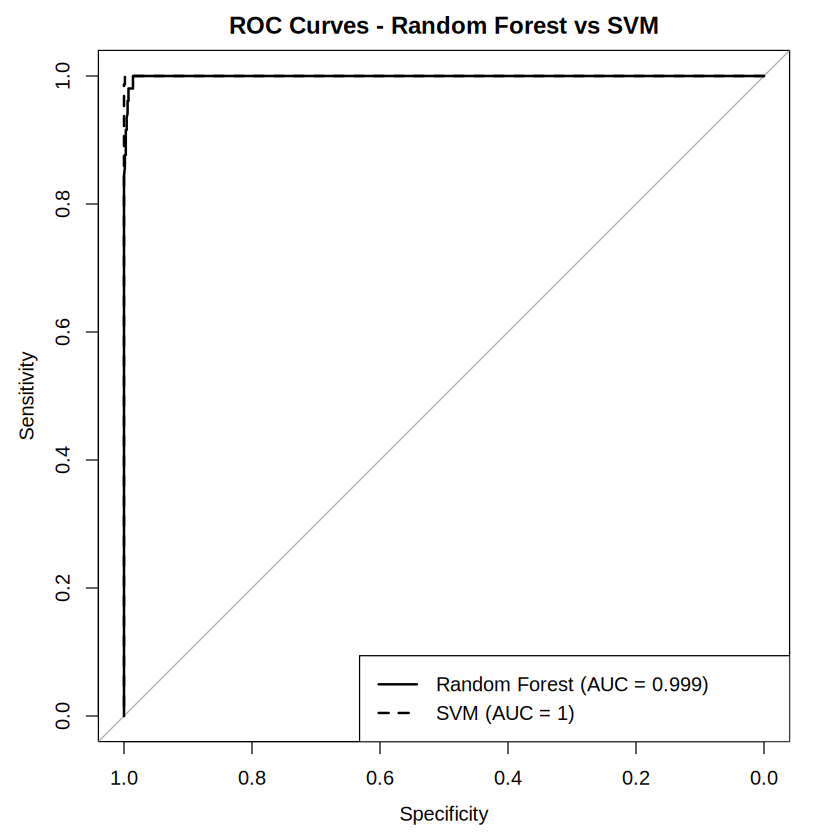

In [24]:
plot(
  rf_roc,
  main = "ROC Curves - Random Forest vs SVM",
  lwd = 2
)

plot(
  svm_roc,
  add = TRUE,
  lwd = 2,
  lty = 2
)

legend(
  "bottomright",
  legend = c(
    paste0("Random Forest (AUC = ", round(rf_auc, 3), ")"),
    paste0("SVM (AUC = ", round(svm_auc, 3), ")")
  ),
  lwd = 2,
  lty = c(1, 2)
)

In [25]:
importance_table <- as.data.frame(importance(rf_model)) %>%
  rownames_to_column("Feature") %>%
  arrange(desc(MeanDecreaseGini))

importance_table

Feature,No,Yes,MeanDecreaseAccuracy,MeanDecreaseGini
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Frequency,17.809479,30.18684,32.30057,339.03989
Monetary,10.783757,23.00165,22.42468,219.63288
TotalQuantity,9.282757,23.40552,24.77623,171.43787
PurchaseFrequency,25.146771,33.93845,40.07692,128.01151
UniqueProducts,3.440058,36.71664,33.42693,91.11508
Recency,-2.313381,14.41319,11.54177,34.03568
AvgTransactionValue,16.042571,10.90679,20.02757,33.57301


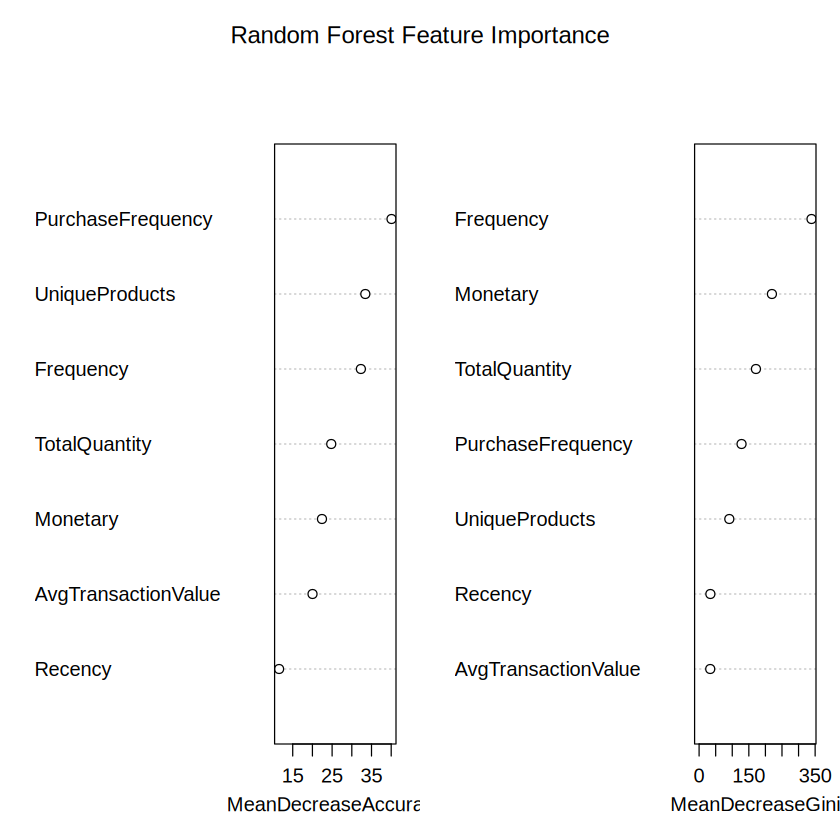

In [26]:
varImpPlot(
  rf_model,
  main = "Random Forest Feature Importance"
)

In [27]:
plot_ly(
  pca_data,
  x = ~PC1,
  y = ~PC2,
  z = ~PC3,
  color = ~Cluster,
  type = "scatter3d",
  mode = "markers",
  marker = list(size = 4)
) %>%
  layout(
    title = "Interactive 3D PCA Customer Segments",
    scene = list(
      xaxis = list(title = "PC1"),
      yaxis = list(title = "PC2"),
      zaxis = list(title = "PC3")
    )
  )

HTML widgets cannot be represented in plain text (need html)

In [28]:
# Automatically generate a simple segment interpretation table
recommendations <- cluster_profile %>%
  mutate(
    Segment_Type = case_when(
      Monetary >= quantile(Monetary, 0.75) &
        Frequency >= quantile(Frequency, 0.75) &
        Recency <= quantile(Recency, 0.50) ~ "High-value loyal customers",

      Monetary >= quantile(Monetary, 0.75) &
        Frequency < quantile(Frequency, 0.75) ~ "High-spend reactivation opportunity",

      Frequency >= quantile(Frequency, 0.50) &
        Monetary < quantile(Monetary, 0.75) ~ "Frequent moderate-value customers",

      TRUE ~ "Low-engagement customers"
    ),

    Marketing_Strategy = case_when(
      Segment_Type == "High-value loyal customers" ~
        "VIP rewards, loyalty benefits, premium offers and early access",

      Segment_Type == "High-spend reactivation opportunity" ~
        "Personalized reactivation, reminders and targeted offers",

      Segment_Type == "Frequent moderate-value customers" ~
        "Bundles, cross-selling and volume-based promotions",

      TRUE ~
        "Introductory offers, product discovery and low-cost engagement campaigns"
    )
  ) %>%
  select(Cluster, Segment_Type, Marketing_Strategy)

recommendations

Cluster,Segment_Type,Marketing_Strategy
<fct>,<chr>,<chr>
1,Low-engagement customers,"Introductory offers, product discovery and low-cost engagement campaigns"
2,Low-engagement customers,"Introductory offers, product discovery and low-cost engagement campaigns"
3,High-value loyal customers,"VIP rewards, loyalty benefits, premium offers and early access"
4,Frequent moderate-value customers,"Bundles, cross-selling and volume-based promotions"


In [29]:
cat("========== FINAL SUMMARY ==========" , "\n")
cat("Customers analysed:", nrow(customer_model), "\n")
cat("Selected K:", optimal_k, "\n")
cat("K-Means Silhouette Score:", round(sil_avg, 4), "\n")
cat("Hierarchical Silhouette Score:", round(sil_hc_avg, 4), "\n")
cat("High-value cluster:", high_value_cluster, "\n")
cat("Random Forest AUC:", round(rf_auc, 4), "\n")
cat("SVM AUC:", round(svm_auc, 4), "\n")
cat("===================================" , "\n")

========== FINAL SUMMARY ========== 
Customers analysed: 4338 
Selected K: 4 
K-Means Silhouette Score: 0.2901 
Hierarchical Silhouette Score: 0.2216 
High-value cluster: 3 
Random Forest AUC: 0.9992 
SVM AUC: 1 
